In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from sklearn.feature_selection import SelectKBest, mutual_info_classif


In [ ]:

# replace the filename below if needed
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
print(df.head())
print(df.info())

Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

**Dataset quality checks**

In [ ]:
# Missing values (including blanks)
missing = df.isna().sum().sort_values(ascending=False)
print("Missing values:\n", missing[missing > 0])

# Check blank strings in TotalCharges (common issue)
blank_total = (df["TotalCharges"].astype(str).str.strip() == "").sum()
print("Blank strings in TotalCharges:", blank_total)

# Class balance
print("\nChurn distribution:\n", df["Churn"].value_counts())
print("\nChurn ratio:\n", df["Churn"].value_counts(normalize=True).round(3))


Missing values:
 Series([], dtype: int64)
Blank strings in TotalCharges: 11

Churn distribution:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn ratio:
 Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


**EDA visuals**

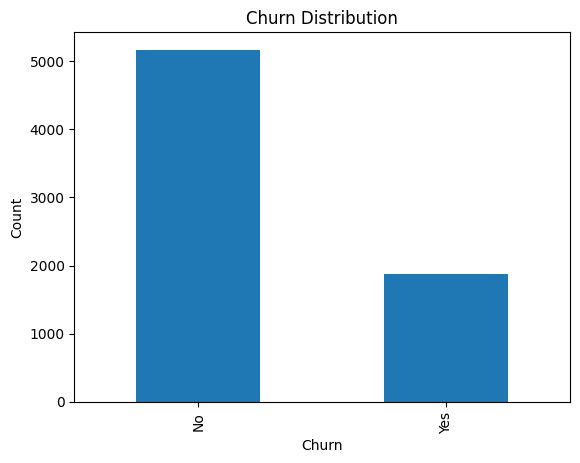

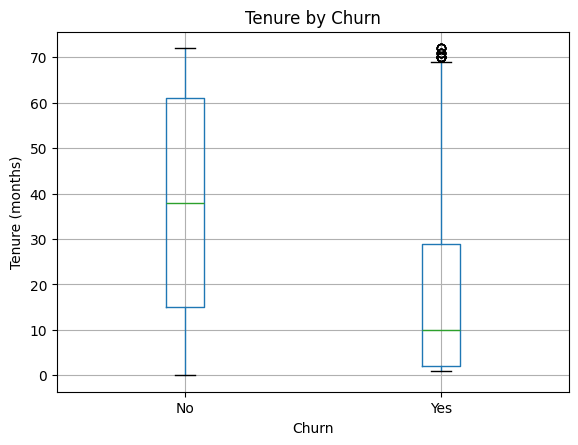

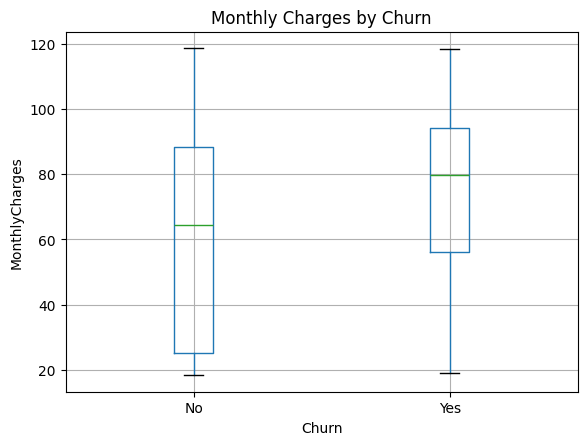

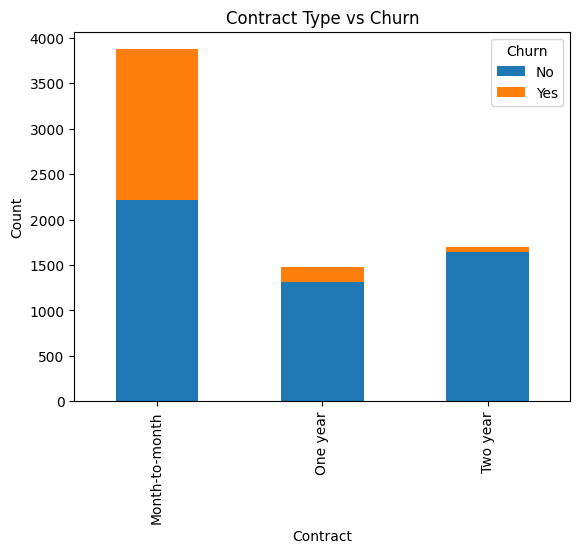

In [ ]:
# 1) Target distribution
df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# Convert TotalCharges for EDA plots (temporary)
tmp = df.copy()
tmp["TotalCharges"] = pd.to_numeric(tmp["TotalCharges"].astype(str).str.strip(), errors="coerce")

# 2) Tenure vs churn
tmp.boxplot(column="tenure", by="Churn")
plt.title("Tenure by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.show()

# 3) MonthlyCharges vs churn
tmp.boxplot(column="MonthlyCharges", by="Churn")
plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("MonthlyCharges")
plt.show()

# 4) Contract vs churn (countplot style without seaborn)
ct = pd.crosstab(df["Contract"], df["Churn"])
ct.plot(kind="bar", stacked=True)
plt.title("Contract Type vs Churn")
plt.xlabel("Contract")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()


**Define X/y, fix types, split**

In [ ]:
data = df.copy()

# Drop ID column
data = data.drop(columns=["customerID"])

# Target
y = data["Churn"].map({"No": 0, "Yes": 1})
X = data.drop(columns=["Churn"])

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train churn ratio:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test churn ratio :", y_test.value_counts(normalize=True).round(3).to_dict())


Train churn ratio: {0: 0.735, 1: 0.265}
Test churn ratio : {0: 0.735, 1: 0.265}


**Preprocessing pipeline (numeric + categorical)**

In [ ]:
numeric_features = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [c for c in X.columns if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    # Convert TotalCharges safely inside pipeline using imputation after coercion step below
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# We will convert TotalCharges to numeric BEFORE pipeline (simplest + clear)
def convert_totalcharges(df_in):
    df_out = df_in.copy()
    df_out["TotalCharges"] = pd.to_numeric(df_out["TotalCharges"].astype(str).str.strip(), errors="coerce")
    return df_out

X_train2 = convert_totalcharges(X_train)
X_test2  = convert_totalcharges(X_test)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


**Helper function for evaluation**

In [ ]:
def eval_model(model, Xtr, ytr, Xte, yte, name="Model"):
    model.fit(Xtr, ytr)
    pred_tr = model.predict(Xtr)
    pred_te = model.predict(Xte)

    results = {
        "Model": name,
        "Train Accuracy": accuracy_score(ytr, pred_tr),
        "Test Accuracy": accuracy_score(yte, pred_te),
        "Test Precision": precision_score(yte, pred_te),
        "Test Recall": recall_score(yte, pred_te),
        "Test F1": f1_score(yte, pred_te),
    }
    print("\n", name)
    print(classification_report(yte, pred_te, digits=3))
    cm = confusion_matrix(yte, pred_te)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Confusion Matrix: {name}")
    plt.show()
    return results


**MLP model (with described architecture)**


 Neural Net (MLP)
              precision    recall  f1-score   support

           0      0.815     0.864     0.839      1035
           1      0.548     0.457     0.499       374

    accuracy                          0.756      1409
   macro avg      0.682     0.660     0.669      1409
weighted avg      0.744     0.756     0.748      1409



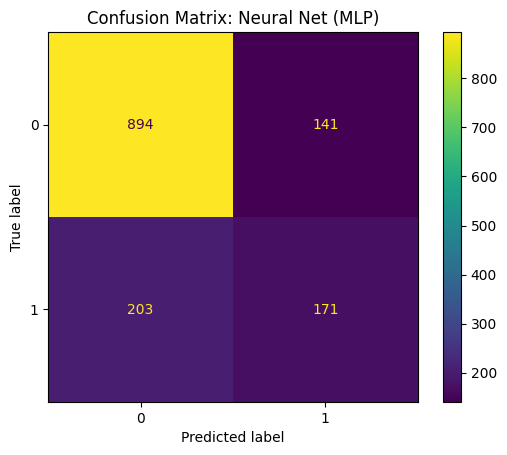

{'Model': 'Neural Net (MLP)',
 'Train Accuracy': 0.8926162584309549,
 'Test Accuracy': 0.7558552164655784,
 'Test Precision': 0.5480769230769231,
 'Test Recall': 0.4572192513368984,
 'Test F1': 0.49854227405247814}

In [ ]:
mlp = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(64, 32),   # 2 hidden layers
        activation="relu",
        solver="adam",
        alpha=0.0005,                  # L2 regularization
        max_iter=300,
        random_state=42
    ))
])

mlp_results = eval_model(mlp, X_train2, y_train, X_test2, y_test, name="Neural Net (MLP)")
mlp_results


**Baseline KNN + Logistic Regression**


 KNN (Baseline)
              precision    recall  f1-score   support

           0      0.844     0.832     0.838      1035
           1      0.553     0.575     0.564       374

    accuracy                          0.764      1409
   macro avg      0.698     0.703     0.701      1409
weighted avg      0.767     0.764     0.765      1409



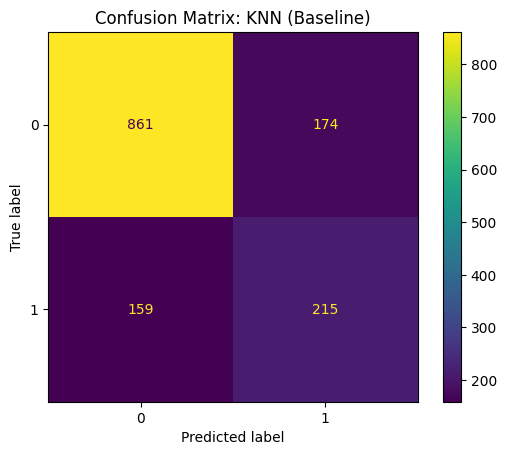


 LogReg (Baseline)
              precision    recall  f1-score   support

           0      0.849     0.895     0.871      1035
           1      0.657     0.559     0.604       374

    accuracy                          0.806      1409
   macro avg      0.753     0.727     0.738      1409
weighted avg      0.798     0.806     0.800      1409



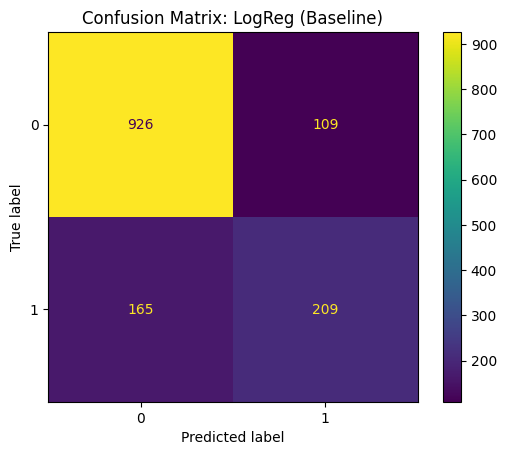

In [ ]:
knn = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", KNeighborsClassifier())
])

logreg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(
        max_iter=1000,
        solver="liblinear"
    ))
])

knn_base_results = eval_model(knn, X_train2, y_train, X_test2, y_test, name="KNN (Baseline)")
logreg_base_results = eval_model(logreg, X_train2, y_train, X_test2, y_test, name="LogReg (Baseline)")


**GridSearchCV for both models**

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# KNN grid
knn_grid = {
    "clf__n_neighbors": [3, 5, 7, 11, 15, 21],
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2]  # 1 = Manhattan, 2 = Euclidean
}

knn_tune = GridSearchCV(
    knn, knn_grid, scoring="f1", cv=cv, n_jobs=-1
)
knn_tune.fit(X_train2, y_train)

print("Best KNN params:", knn_tune.best_params_)
print("Best KNN CV F1:", knn_tune.best_score_)

# Logistic Regression grid
logreg_grid = {
    "clf__C": [0.1, 0.3, 1, 3, 10],
    "clf__class_weight": [None, "balanced"]
}

logreg_tune = GridSearchCV(
    logreg, logreg_grid, scoring="f1", cv=cv, n_jobs=-1
)
logreg_tune.fit(X_train2, y_train)

print("\nBest LogReg params:", logreg_tune.best_params_)
print("Best LogReg CV F1:", logreg_tune.best_score_)


Best KNN params: {'clf__n_neighbors': 21, 'clf__p': 2, 'clf__weights': 'uniform'}
Best KNN CV F1: 0.5949819838106868

Best LogReg params: {'clf__C': 3, 'clf__class_weight': 'balanced'}
Best LogReg CV F1: 0.6300762973012926


**Add feature selection into pipeline + tune k**

In [ ]:
# Feature selection step (after preprocessing)
fs = SelectKBest(score_func=mutual_info_classif, k=20)

knn_fs_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", fs),
    ("clf", KNeighborsClassifier())
])

logreg_fs_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", fs),
    ("clf", LogisticRegression(max_iter=1000, solver="liblinear"))
])

# Tune both hyperparams + k together (simple and strong)
knn_fs_grid = {
    "select__k": [10, 15, 20, 25, 30],
    "clf__n_neighbors": [5, 7, 11, 15, 21],
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2]
}

logreg_fs_grid = {
    "select__k": [10, 15, 20, 25, 30],
    "clf__C": [0.1, 0.3, 1, 3, 10],
    "clf__class_weight": [None, "balanced"]
}

knn_fs_tune = GridSearchCV(knn_fs_pipe, knn_fs_grid, scoring="f1", cv=cv, n_jobs=-1)
knn_fs_tune.fit(X_train2, y_train)

logreg_fs_tune = GridSearchCV(logreg_fs_pipe, logreg_fs_grid, scoring="f1", cv=cv, n_jobs=-1)
logreg_fs_tune.fit(X_train2, y_train)

print("Best KNN (FS) params:", knn_fs_tune.best_params_)
print("Best KNN (FS) CV F1:", knn_fs_tune.best_score_)

print("\nBest LogReg (FS) params:", logreg_fs_tune.best_params_)
print("Best LogReg (FS) CV F1:", logreg_fs_tune.best_score_)


Best KNN (FS) params: {'clf__n_neighbors': 21, 'clf__p': 1, 'clf__weights': 'uniform', 'select__k': 30}
Best KNN (FS) CV F1: 0.5917400538186814

Best LogReg (FS) params: {'clf__C': 1, 'clf__class_weight': 'balanced', 'select__k': 30}
Best LogReg (FS) CV F1: 0.628673542327442


**Evaluate final tuned models on test set + build comparison table**

,Model,Selected Features (k),CV Score (F1),Accuracy,Precision,Recall,F1-Score
0,KNN (Tuned + FS),30,0.591740,0.785664,0.599448,0.580214,0.589674
1,LogReg (Tuned + FS),30,0.628674,0.740951,0.507719,0.791444,0.618600


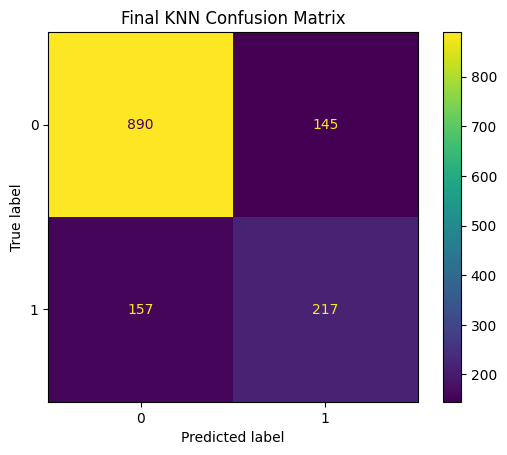

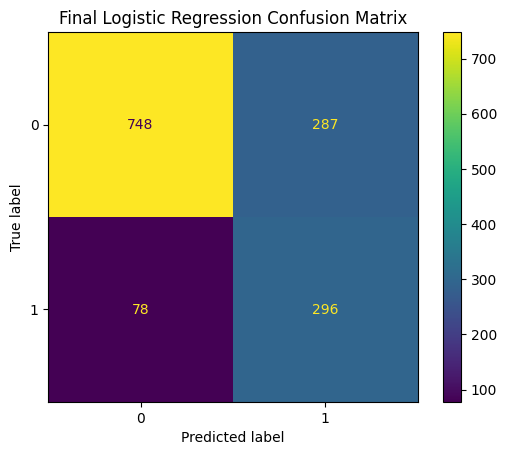

In [ ]:
final_knn = knn_fs_tune.best_estimator_
final_logreg = logreg_fs_tune.best_estimator_

# Evaluate on test set
knn_final_pred = final_knn.predict(X_test2)
logreg_final_pred = final_logreg.predict(X_test2)

def summarize_final(name, best_cv, estimator, y_true, y_pred):
    return {
        "Model": name,
        "Selected Features (k)": estimator.named_steps["select"].k,
        "CV Score (F1)": best_cv,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

table4 = pd.DataFrame([
    summarize_final("KNN (Tuned + FS)", knn_fs_tune.best_score_, final_knn, y_test, knn_final_pred),
    summarize_final("LogReg (Tuned + FS)", logreg_fs_tune.best_score_, final_logreg, y_test, logreg_final_pred)
])

display(table4)

# Confusion matrices
ConfusionMatrixDisplay(confusion_matrix(y_test, knn_final_pred)).plot()
plt.title("Final KNN Confusion Matrix")
plt.show()

ConfusionMatrixDisplay(confusion_matrix(y_test, logreg_final_pred)).plot()
plt.title("Final Logistic Regression Confusion Matrix")
plt.show()
